In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a continent mapping
continent_map = {
    'Africa': ['Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo', 'Cote d\'Ivoire', 'Democratic Republic of the Congo', 'Djibouti', 'Egypt', 'Equatorial Guinea', 'Eritrea', 'Eswatini', 'Ethiopia', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Kenya', 'Lesotho', 'Liberia', 'Libya', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Rwanda', 'Sao Tome and Principe', 'Senegal', 'Seychelles', 'Sierra Leone', 'Somalia', 'South Africa', 'South Sudan', 'Sudan', 'Tanzania', 'Togo', 'Tunisia', 'Uganda', 'Zambia', 'Zimbabwe'],
    'Asia': ['Afghanistan', 'Armenia', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Bhutan', 'Brunei Darussalam', 'Cambodia', 'China', 'Cyprus', 'Georgia', 'India', 'Indonesia', 'Iran', 'Iraq', 'Israel', 'Japan', 'Jordan', 'Kazakhstan', 'Kuwait', 'Kyrgyzstan', 'Laos', 'Lebanon', 'Malaysia','Maldives', 'Mongolia', 'Myanmar', 'Nepal', 'North Korea', 'Oman', 'Pakistan', 'Palestine', 'Philippines', 'Qatar', 'Saudi Arabia', 'Singapore', 'South Korea', 'Sri Lanka', 'Syria', 'Taiwan', 'Tajikistan', 'Thailand', 'Timor-Leste', 'Turkey', 'Turkmenistan', 'United Arab Emirates', 'Uzbekistan', 'Vietnam', 'Yemen'],
    'Europe': ['Albania', 'Andorra', 'Austria', 'Belarus', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Czech Republic', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Italy', 'Kosovo', 'Latvia', 'Liechtenstein', 'Lithuania', 'Luxembourg', 'Malta', 'Moldova', 'Monaco', 'Montenegro', 'Netherlands', 'North Macedonia', 'Norway', 'Poland', 'Portugal', 'Romania', 'Russia', 'San Marino', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Ukraine', 'United Kingdom', 'Vatican City'],
    'North America': ['Canada', 'Greenland', 'Mexico', 'United States'],
    'Oceania': ['Australia', 'Fiji', 'New Zealand', 'Papua New Guinea'],
    'South America': ['Argentina', 'Bolivia', 'Brazil', 'Chile', 'Colombia', 'Ecuador', 'Guyana', 'Paraguay', 'Peru', 'Suriname', 'Uruguay', 'Venezuela']
}

len(continent_map["South America"])

12

In [47]:
dataset = pd.read_csv ("World Energy Consumption.csv")

In [48]:
col_electricity = ['low_carbon_electricity',
            'nuclear_electricity',
            'oil_electricity',
            'other_renewable_electricity',
            'other_renewable_exc_biofuel_electricity',
            'solar_electricity',
            'wind_electricity',
            'fossil_electricity',
            'gas_electricity',
            'hydro_electricity',
            'biofuel_electricity',
            'coal_electricity']
col_cons =['biofuel_consumption',
           'coal_consumption',
           'fossil_fuel_consumption',
           'gas_consumption',
           'hydro_consumption',
           'low_carbon_consumption',
           'nuclear_consumption',
           'oil_consumption',
           'solar_consumption']

In [49]:
dataset = dataset.groupby(['year','country'])[col_electricity].sum().sum(axis=1).to_frame('electricity_generation').reset_index("country")
dataset

,country,electricity_generation
year,,
1900,Afghanistan,0.000
1900,Africa,0.000
1900,Africa (Shift),0.000
1900,Albania,0.000
1900,Algeria,0.000
...,...,...
2022,Vietnam,527.021
2022,Western Africa (EI),55.687
2022,World,57832.830


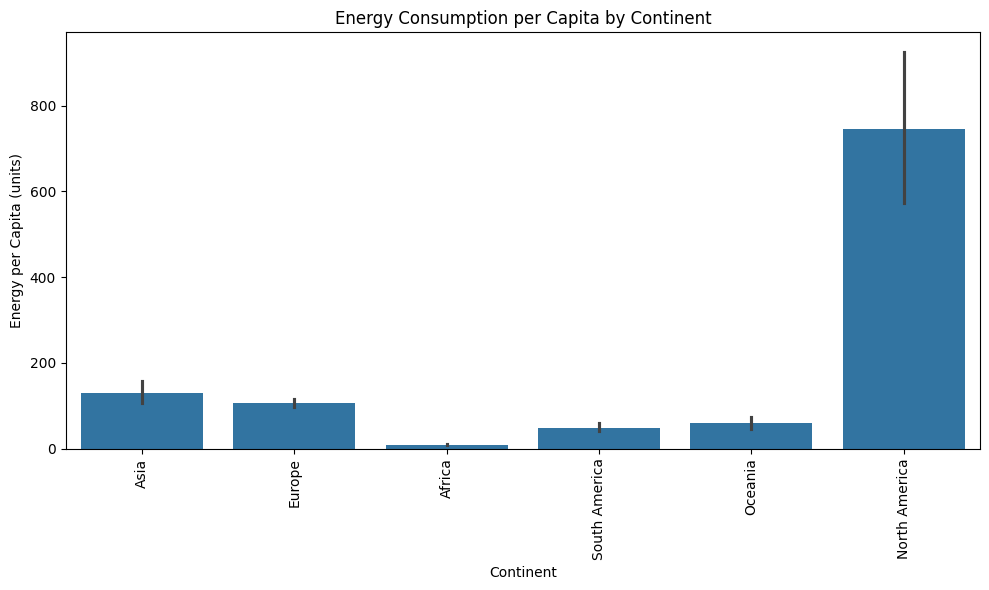

In [52]:
# Filter out rows with missing 'energy_per_capita' values
dataset_filtered = dataset[dataset['electricity_generation'].notna()]

# Add a 'continent' column to the dataset
dataset_filtered['continent'] = dataset_filtered['country'].map(lambda x: next((k for k, v in continent_map.items() if x in v), None))
dataset_filtered = dataset_filtered[dataset_filtered['continent'].notna()]

# Plot energy consumption per capita across continents
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=dataset_filtered, x='continent', y='electricity_generation', ax=ax)
ax.set_title('Energy Consumption per Capita by Continent')
ax.set_xlabel('Continent')
ax.set_ylabel('Energy per Capita (units)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [53]:
dataset_filtered

,country,electricity_generation,continent
year,,,
1900,Afghanistan,0.000,Asia
1900,Albania,0.000,Europe
1900,Algeria,0.000,Africa
1900,Angola,0.000,Africa
1900,Argentina,0.000,South America
...,...,...,...
2022,Uzbekistan,10.996,Asia
2022,Venezuela,133.294,South America
2022,Vietnam,527.021,Asia


In [55]:
dataset_continentes = dataset_filtered.groupby(["year","continent"])["electricity_generation"].sum().to_frame('electricity_generation').reset_index("continent")
dataset_continentes.head()

,continent,electricity_generation
year,,
1900,Africa,0.0
1900,Asia,0.0
1900,Europe,0.0
1900,North America,0.0
1900,Oceania,0.0


In [75]:
dataset_continentes_filt = dataset_continentes[dataset_continentes["electricity_generation"]>0]
dataset_continentes_filt = dataset_continentes_filt[dataset_continentes_filt.index>=1985]
dataset_continentes_filt

,continent,electricity_generation
year,,
1985,Africa,335.744
1985,Asia,3368.266
1985,Europe,6373.662
1985,North America,6423.774
1985,Oceania,268.917
...,...,...
2022,Asia,31197.503
2022,Europe,9356.613
2022,North America,10662.530


In [57]:
dataset_sudamerica = dataset_continentes_filt[dataset_continentes_filt["continent"]=="South America"]

In [79]:
from statsmodels.tools.eval_measures import mse,rmse 
from sklearn.metrics import r2_score
import numpy as np
from prophet import Prophet

train_size = np.arange(0.6,0.9,0.02)
lista_size = []
lista_r2_score = []
lista_rmse_error = []
lista_mse_error = []
diccionario = {}
def best_train_size (continente, train_size):
    for size in train_size:
        
        country_df = dataset_continentes_filt[dataset_continentes_filt["continent"] == continente]
        
        
        country_filt = country_df[["electricity_generation"]]
        
        
        index = round(size*country_df.shape[0])
        country_train = country_filt.iloc[:index]
        country_test = country_filt.iloc[index:]
        
        
        df_prophet_country = country_train
        df_prophet_country.index = pd.to_datetime(df_prophet_country.index, format='%Y')
        # Asegurarse de que el índice de df_test sea un DatetimeIndex
        country_test.index = pd.to_datetime(country_test.index, format='%Y')  # Si el índice son solo años
        
      
        # Reformatear los datos para Prophet (usando df_train para entrenamiento)
        df_prophet_country = country_train.reset_index().rename(columns={"year": "ds", "electricity_generation": "y"})

         # Ajustar el modelo
        model_prophet = Prophet()
    
        model_prophet.fit(df_prophet_country)
        
        # Crear un DataFrame de fechas futuras
        future = model_prophet.make_future_dataframe(periods=country_test.shape[0], freq="Y")
  
        # Generar predicciones
        forecast = model_prophet.predict(future).set_index(country_filt.index)
        
        # Graficar resultados
        #fig = model_prophet.plot(forecast)
        #plt.title("Electricity Generation Forecast using Prophet")
        
        # Trazar los valores reales de df_test en la misma gráfica
        #plt.plot(country_test.index,country_test["electricity_generation"], 'o', color='red', label='Real Data')
        
        # Configuración del gráfico
        #plt.xlabel("Year")
        #plt.ylabel("Electricity Generation (TWh)")
        #plt.grid(True)
        #plt.legend()  # Mostrar la leyenda para las dos series
        #plt.show()
    
    
     
        # Si solo te interesan los valores de 'yhat' (predicciones), puedes hacer lo siguiente:
        predicted_values = forecast[['ds', 'yhat']]
        predicted_values = predicted_values.set_index(country_filt.index)
        y_pred = predicted_values.iloc[country_train.shape[0]:,:]["yhat"]
             
        
        
        y_true = country_test["electricity_generation"]
        
        r2_pro = r2_score(y_true,y_pred)
        mse_error = mse(y_true,y_pred)
        rmse_error = rmse(y_true,y_pred)
        mse_error, rmse_error

        lista_size.append(size)
        lista_r2_score.append(r2_pro)
        lista_rmse_error.append(rmse_error)
        lista_mse_error.append(mse_error)

        prueba = {"size":lista_size,"r2_score":lista_r2_score,"rmse_error":lista_rmse_error,"mse_error":lista_mse_error}
        # Encontrar el índice del valor máximo de r2_score
        max_index = prueba['rmse_error'].index(min(prueba['rmse_error']))

        
        # Obtener el tamaño correspondiente al r2_score máximo
        best_size = np.round(prueba['size'][max_index],2)
        
        print(f" Para train_size = {size} -----> r2_score = {r2_pro}, rmse_error = {rmse_error}, mse_error = {mse_error}")
    print(max(prueba['r2_score']), best_size)
    return best_size

In [80]:
best_train_size ("South America",np.arange(0.6,0.9,0.02))        

20:49:45 - cmdstanpy - INFO - Chain [1] start processing
20:49:45 - cmdstanpy - INFO - Chain [1] done processing
/home/nicolas/.pyenv/versions/3.10.6/envs/energy_production/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
20:49:45 - cmdstanpy - INFO - Chain [1] start processing
20:49:45 - cmdstanpy - INFO - Chain [1] done processing
/home/nicolas/.pyenv/versions/3.10.6/envs/energy_production/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
20:49:45 - cmdstanpy - INFO - Chain [1] start processing


 Para train_size = 0.6 -----> r2_score = -2.8025394612292476, rmse_error = 376.09020357101565, mse_error = 141443.841222088
 Para train_size = 0.62 -----> r2_score = -3.539435735461608, rmse_error = 363.30809176686046, mse_error = 131992.7695432775


20:49:45 - cmdstanpy - INFO - Chain [1] done processing
/home/nicolas/.pyenv/versions/3.10.6/envs/energy_production/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
20:49:45 - cmdstanpy - INFO - Chain [1] start processing
20:49:45 - cmdstanpy - INFO - Chain [1] done processing
/home/nicolas/.pyenv/versions/3.10.6/envs/energy_production/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
20:49:45 - cmdstanpy - INFO - Chain [1] start processing


 Para train_size = 0.64 -----> r2_score = -3.539435735461608, rmse_error = 363.30809176686046, mse_error = 131992.7695432775
 Para train_size = 0.66 -----> r2_score = -5.1978170071464005, rmse_error = 342.69633141880126, mse_error = 117440.77556790487


20:49:45 - cmdstanpy - INFO - Chain [1] done processing
/home/nicolas/.pyenv/versions/3.10.6/envs/energy_production/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
20:49:45 - cmdstanpy - INFO - Chain [1] start processing
20:49:46 - cmdstanpy - INFO - Chain [1] done processing
/home/nicolas/.pyenv/versions/3.10.6/envs/energy_production/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
20:49:46 - cmdstanpy - INFO - Chain [1] start processing


...

 Para train_size = 0.8400000000000002 -----> r2_score = -39.85600883887505, rmse_error = 369.6584624399199, mse_error = 136647.37885344567
 Para train_size = 0.8600000000000002 -----> r2_score = -30.013870585213084, rmse_error = 303.74725601111174, mse_error = 92262.39553427987


/home/nicolas/.pyenv/versions/3.10.6/envs/energy_production/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
20:49:47 - cmdstanpy - INFO - Chain [1] start processing
20:49:47 - cmdstanpy - INFO - Chain [1] done processing
/home/nicolas/.pyenv/versions/3.10.6/envs/energy_production/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
20:49:47 - cmdstanpy - INFO - Chain [1] start processing
20:49:47 - cmdstanpy - INFO - Chain [1] done processing


 Para train_size = 0.8800000000000002 -----> r2_score = -30.013870585213084, rmse_error = 303.74725601111174, mse_error = 92262.39553427987
 Para train_size = 0.9000000000000002 -----> r2_score = -29.58019561176721, rmse_error = 314.57870568709586, mse_error = 98959.76207176849
-2.8025394612292476 0.86


/home/nicolas/.pyenv/versions/3.10.6/envs/energy_production/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


np.float64(0.86)

In [73]:
dataset_continentes_filt

,continent,electricity_generation
year,,
1965,Africa,3.382
1965,Asia,215.129
1965,Europe,525.324
1965,North America,347.211
1965,Oceania,30.720
...,...,...
2022,Asia,31197.503
2022,Europe,9356.613
2022,North America,10662.530


20:50:04 - cmdstanpy - INFO - Chain [1] start processing
20:50:04 - cmdstanpy - INFO - Chain [1] done processing
/home/nicolas/.pyenv/versions/3.10.6/envs/energy_production/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


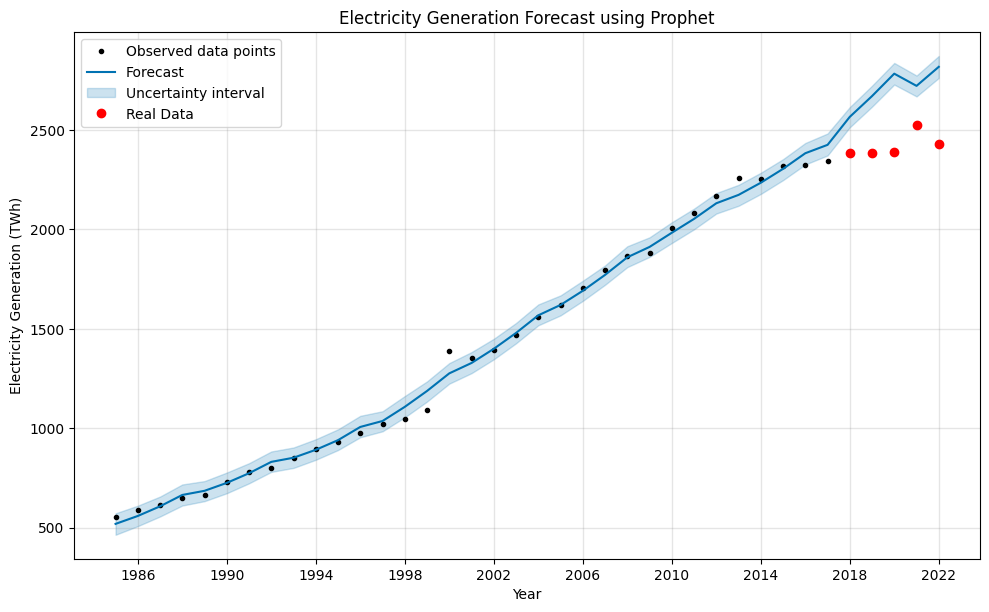

In [82]:
country_df = dataset_continentes_filt[dataset_continentes_filt["continent"] == "South America"]
        
        
country_filt = country_df[["electricity_generation"]]

size = 0.86
index = round(size*country_df.shape[0])
country_train = country_filt.iloc[:index]
country_test = country_filt.iloc[index:]


df_prophet_country = country_train
df_prophet_country.index = pd.to_datetime(df_prophet_country.index, format='%Y')
# Asegurarse de que el índice de df_test sea un DatetimeIndex
country_test.index = pd.to_datetime(country_test.index, format='%Y')  # Si el índice son solo años


# Reformatear los datos para Prophet (usando df_train para entrenamiento)
df_prophet_country = country_train.reset_index().rename(columns={"year": "ds", "electricity_generation": "y"})

 # Ajustar el modelo
model_prophet = Prophet()

model_prophet.fit(df_prophet_country)

# Crear un DataFrame de fechas futuras
future = model_prophet.make_future_dataframe(periods=country_test.shape[0], freq="Y")

# Generar predicciones
forecast = model_prophet.predict(future).set_index(country_filt.index)

# Graficar resultados
fig = model_prophet.plot(forecast)
plt.title("Electricity Generation Forecast using Prophet")

#Trazar los valores reales de df_test en la misma gráfica
plt.plot(country_test.index,country_test["electricity_generation"], 'o', color='red', label='Real Data')

# Configuración del gráfico
plt.xlabel("Year")
plt.ylabel("Electricity Generation (TWh)")
plt.grid(True)
plt.legend()  # Mostrar la leyenda para las dos series
plt.show()


In [88]:
sudamerica

,Entity,Year,Electricity generation - TWh
0,Argentina,1985,45.303726
1,Argentina,1986,49.022194
2,Argentina,1987,52.115280
3,Argentina,1988,52.499520
4,Argentina,1989,50.862812
...,...,...,...
386,Venezuela,2019,85.180000
387,Venezuela,2020,79.880000
388,Venezuela,2021,82.570000
389,Venezuela,2022,84.660000


In [108]:
sudamerica = pd.read_csv("sudamerica.csv")

sudamerica = sudamerica.groupby("Year")["Electricity generation - TWh"].sum().to_frame('electricity_generation')

In [124]:
from statsmodels.tools.eval_measures import mse,rmse 
from sklearn.metrics import r2_score
import numpy as np
from prophet import Prophet

train_size = np.arange(0.5,0.98,0.02)
lista_size = []
lista_r2_score = []
lista_rmse_error = []
lista_mse_error = []
diccionario = {}
def best_train_size (train_size):
    for size in train_size:
        

        
        
        country_filt = sudamerica[["electricity_generation"]]
        
        
        index = round(size*country_df.shape[0])
        country_train = country_filt.iloc[:index]
        country_test = country_filt.iloc[index:]
        
        
        df_prophet_country = country_train
        df_prophet_country.index = pd.to_datetime(df_prophet_country.index, format='%Y')
        # Asegurarse de que el índice de df_test sea un DatetimeIndex
        country_test.index = pd.to_datetime(country_test.index, format='%Y')  # Si el índice son solo años
               # Reformatear los datos para Prophet (usando df_train para entrenamiento)
        df_prophet_country = country_train.reset_index().rename(columns={"Year": "ds", "electricity_generation": "y"})

         # Ajustar el modelo
        model_prophet = Prophet()
    
        model_prophet.fit(df_prophet_country)
        
        # Crear un DataFrame de fechas futuras
        future = model_prophet.make_future_dataframe(periods=country_test.shape[0], freq="Y")
  
        # Generar predicciones
        forecast = model_prophet.predict(future).set_index(country_filt.index)
        
        # Graficar resultados
        #fig = model_prophet.plot(forecast)
        #plt.title("Electricity Generation Forecast using Prophet")
        
        # Trazar los valores reales de df_test en la misma gráfica
        #plt.plot(country_test.index,country_test["electricity_generation"], 'o', color='red', label='Real Data')
        
        # Configuración del gráfico
        #plt.xlabel("Year")
        #plt.ylabel("Electricity Generation (TWh)")
        #plt.grid(True)
        #plt.legend()  # Mostrar la leyenda para las dos series
        #plt.show()
    
    
     
        # Si solo te interesan los valores de 'yhat' (predicciones), puedes hacer lo siguiente:
        predicted_values = forecast[['ds', 'yhat']]
        predicted_values = predicted_values.set_index(country_filt.index)
        y_pred = predicted_values.iloc[country_train.shape[0]:,:]["yhat"]
             
        
        
        y_true = country_test["electricity_generation"]
        
        r2_pro = r2_score(y_true,y_pred)
        mse_error = mse(y_true,y_pred)
        rmse_error = rmse(y_true,y_pred)
        mse_error, rmse_error

        lista_size.append(size)
        lista_r2_score.append(r2_pro)
        lista_rmse_error.append(rmse_error)
        lista_mse_error.append(mse_error)

        prueba = {"size":lista_size,"r2_score":lista_r2_score,"rmse_error":lista_rmse_error,"mse_error":lista_mse_error}
        # Encontrar el índice del valor máximo de r2_score
        max_index = prueba['r2_score'].index(max(prueba['r2_score']))

        
        # Obtener el tamaño correspondiente al r2_score máximo
        best_size = np.round(prueba['size'][max_index],2)
        
        print(f" Para train_size = {size} -----> r2_score = {r2_pro}, rmse_error = {rmse_error}, mse_error = {mse_error}")
    print(max(prueba['r2_score']), best_size)
    return best_size

In [125]:
best_train_size(train_size=np.arange(0.3,0.98,0.02))

21:13:05 - cmdstanpy - INFO - Chain [1] start processing
21:13:05 - cmdstanpy - INFO - Chain [1] done processing
/home/nicolas/.pyenv/versions/3.10.6/envs/energy_production/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
21:13:05 - cmdstanpy - INFO - Chain [1] start processing
21:13:05 - cmdstanpy - INFO - Chain [1] done processing
/home/nicolas/.pyenv/versions/3.10.6/envs/energy_production/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
21:13:05 - cmdstanpy - INFO - Chain [1] start processing
21:13:05 - cmdstanpy - INFO - Chain [1] done processing


 Para train_size = 0.3 -----> r2_score = 0.7729898726462995, rmse_error = 110.4306840562149, mse_error = 12194.935981123557
 Para train_size = 0.32 -----> r2_score = 0.8076598781168025, rmse_error = 97.45175386588076, mse_error = 9496.844331536206
 Para train_size = 0.34 -----> r2_score = 0.8661249627721345, rmse_error = 77.68535309982207, mse_error = 6035.014086244033


/home/nicolas/.pyenv/versions/3.10.6/envs/energy_production/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
21:13:05 - cmdstanpy - INFO - Chain [1] start processing
21:13:05 - cmdstanpy - INFO - Chain [1] done processing
/home/nicolas/.pyenv/versions/3.10.6/envs/energy_production/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
21:13:05 - cmdstanpy - INFO - Chain [1] start processing
21:13:05 - cmdstanpy - INFO - Chain [1] done processing
/home/nicolas/.pyenv/versions/3.10.6/envs/energy_production/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
21:13:05 - cmdstanpy - INFO - Chain [1] start proce

 Para train_size = 0.36000000000000004 -----> r2_score = 0.8386574675888716, rmse_error = 80.98965851585274, mse_error = 6559.324786514438
 Para train_size = 0.38000000000000006 -----> r2_score = 0.8386574675888716, rmse_error = 80.98965851585274, mse_error = 6559.324786514438


/home/nicolas/.pyenv/versions/3.10.6/envs/energy_production/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
21:13:05 - cmdstanpy - INFO - Chain [1] start processing
21:13:05 - cmdstanpy - INFO - Chain [1] done processing
/home/nicolas/.pyenv/versions/3.10.6/envs/energy_production/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
21:13:05 - cmdstanpy - INFO - Chain [1] start processing
21:13:05 - cmdstanpy - INFO - Chain [1] done processing


...

 Para train_size = 0.9200000000000006 -----> r2_score = -3.6791625734991875, rmse_error = 103.28437848379143, mse_error = 10667.662838783077


/home/nicolas/.pyenv/versions/3.10.6/envs/energy_production/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
21:13:10 - cmdstanpy - INFO - Chain [1] start processing
21:13:10 - cmdstanpy - INFO - Chain [1] done processing


 Para train_size = 0.9400000000000006 -----> r2_score = 0.8237794049526674, rmse_error = 14.124284046529336, mse_error = 199.49539982704314
 Para train_size = 0.9600000000000006 -----> r2_score = 0.8237794049526674, rmse_error = 14.124284046529336, mse_error = 199.49539982704314
0.8661249627721345 0.34


/home/nicolas/.pyenv/versions/3.10.6/envs/energy_production/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


np.float64(0.34)

21:18:52 - cmdstanpy - INFO - Chain [1] start processing
21:18:52 - cmdstanpy - INFO - Chain [1] done processing
/home/nicolas/.pyenv/versions/3.10.6/envs/energy_production/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


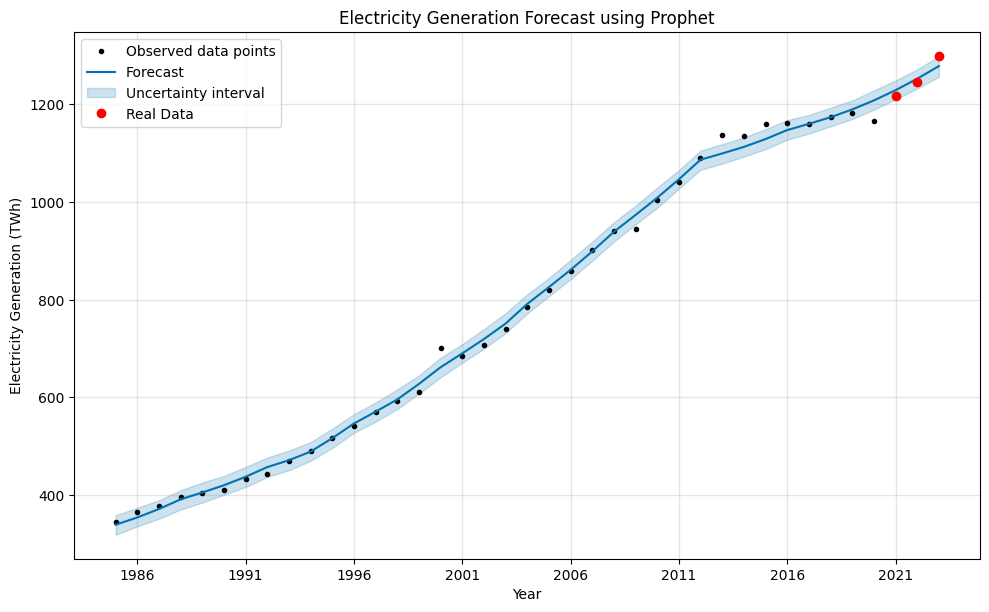

In [132]:

country_filt = sudamerica[["electricity_generation"]]

size = 0.95
index = round(size*country_df.shape[0])
country_train = country_filt.iloc[:index]
country_test = country_filt.iloc[index:]


df_prophet_country = country_train
df_prophet_country.index = pd.to_datetime(df_prophet_country.index, format='%Y')
# Asegurarse de que el índice de df_test sea un DatetimeIndex
country_test.index = pd.to_datetime(country_test.index, format='%Y')  # Si el índice son solo años


# Reformatear los datos para Prophet (usando df_train para entrenamiento)
df_prophet_country = country_train.reset_index().rename(columns={"Year": "ds", "electricity_generation": "y"})

 # Ajustar el modelo
model_prophet = Prophet()

model_prophet.fit(df_prophet_country)

# Crear un DataFrame de fechas futuras
future = model_prophet.make_future_dataframe(periods=country_test.shape[0], freq="Y")

# Generar predicciones
forecast = model_prophet.predict(future).set_index(country_filt.index)

# Graficar resultados
fig = model_prophet.plot(forecast)
plt.title("Electricity Generation Forecast using Prophet")

#Trazar los valores reales de df_test en la misma gráfica
plt.plot(country_test.index,country_test["electricity_generation"], 'o', color='red', label='Real Data')
# Configuración del gráfico
plt.xlabel("Year")
plt.ylabel("Electricity Generation (TWh)")
plt.grid(True)
plt.legend()  # Mostrar la leyenda para las dos series
plt.show()

In [133]:
np.arange(1985,año_seleccionado+1,1)

array([1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995,
       1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006,
       2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017,
       2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028,
       2029])